
Per-cyclone totals:
              sid       sum_raw    dlna_total
0   2009143N17089  1.941054e+10  1.200000e+09
1   2010137N10090  3.972928e+08  6.000000e+08
2   2013281N12098  3.054559e+09  4.150000e+09
3   2013322N13090  2.939170e+08  0.000000e+00
4   2014279N11096  1.292682e+10  3.500000e+09
5   2016341N08092  1.833193e+10  1.000000e+09
6   2017333N06082  2.372201e+08  0.000000e+00
7   2018281N14088  1.043795e+09  9.200000e+08
8   2018314N12093  3.636322e+07  1.600000e+09
9   2019116N02090  1.161542e+10  1.200000e+09
10  2019302N11118  2.678415e+08  3.200000e+09
11  2020136N10088  1.348871e+10  3.200000e+09
12  2020153N13072  7.507160e+06  5.702349e+06
13  2021143N15090  1.628758e+09  2.990000e+09

Scaling rule regression:
                            OLS Regression Results                            
Dep. Variable:             dlna_total   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Le

c:\Users\ketan\.local\share\mamba\envs\climada_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


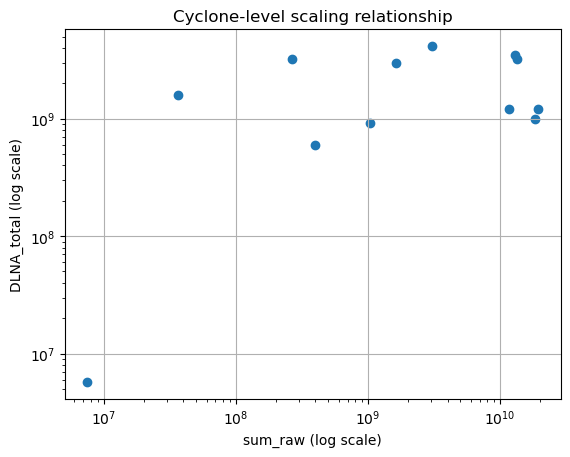

In [1]:
# ------------------------------------------------------------
# CCART v2.0 Scaling Rule Analysis
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load master file
path = r"C:\CMIP data\cmip6\Climada\Projects\ccart-india\data\district_relationships_master_v1_3_rebuild.csv"
df = pd.read_csv(path)

# 1. Aggregate per cyclone
agg = df.groupby("sid").agg(
    sum_raw = ("loss_usd_raw", "sum"),
    dlna_total = ("loss_usd_hwe", "sum")
).reset_index()

print("\nPer-cyclone totals:")
print(agg)

# 2. Remove cyclones with zero DLNA (bad calibration)
agg = agg[agg["dlna_total"] > 0]
agg = agg[agg["sum_raw"] > 0]

# 3. Fit log-log regression
X = np.log(agg["sum_raw"])
y = np.log(agg["dlna_total"])

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print("\nScaling rule regression:")
print(model.summary())

# Extract k and b
a = model.params["const"]
b = model.params["sum_raw"]
k = np.exp(a)

print(f"\nDerived scaling parameters:")
print(f"k = {k}")
print(f"b = {b}")

# 4. Plot relationship
plt.scatter(agg["sum_raw"], agg["dlna_total"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("sum_raw (log scale)")
plt.ylabel("DLNA_total (log scale)")
plt.title("Cyclone-level scaling relationship")
plt.grid(True)
plt.show()
